<img src="https://raw.githubusercontent.com/IDEALLab/EngiOpt/codex/dcc26-workshop-notebooks/workshops/dcc26/assets/engibench_logo.png" width="560"/>

# Notebook 00 — Framing your design problem

*A guided tour, not an exercise sheet. Just run the cells top to bottom and read the prose between them.*

> **Colab users:** click **File ➜ Save a copy in Drive** before editing so your changes persist.

## Where we are in the workshop

You just heard a talk arguing that **engineering design needs better benchmarks** before we can seriously compare ML methods. Great — but *what does a benchmark actually consist of?*

This notebook answers that question by walking through a real engineering problem the way you would if it were sitting on your desk: **what am I designing, under what conditions, by what measure, against what reference?** At each step we write down the answer — and that written-down answer is exactly what a benchmark is.

We'll use [EngiBench](https://github.com/IDEALLab/EngiBench) as the place where these answers live, because it happens to be where we collected them. But the points we're making would apply to any benchmark for engineering design.

**You do not need any ML background for this notebook.** Just Python.


## A concrete problem to anchor the discussion

<img src="https://raw.githubusercontent.com/IDEALLab/EngiOpt/codex/dcc26-workshop-notebooks/workshops/dcc26/assets/engibench_problems.png" width="700"/>

Imagine a colleague walks into your office and says:

> *"I need a 2D bracket that holds a known load at a known point, using no more than 40% of the available material. Can ML help me design it?"*

That sentence is the problem. But before any ML, you — the researcher — need to pin down:

1. **What am I allowed to design?** (What's the output?)
2. **Under what scenarios must the design work?** (What's the input?)
3. **What makes one design better than another?** (What's the metric?)
4. **When is a candidate nonsense?** (What are the rules it must obey?)
5. **What have other people already solved?** (Is there data I can learn from?)
6. **What can I look at?** (Can I see a design, not just a number?)
7. **How do I score a candidate?** (Is there a simulator?)
8. **What does a strong classical baseline look like?** (What do I need to beat?)

These aren't ML questions. They're the questions any careful researcher would write down before touching a model. The rest of this notebook walks through each one on a real problem — the `beams2d` topology-optimisation problem — and shows where the answer lives.


## Install dependencies (Colab / fresh env only)

Skip this if your local environment already has `engibench` installed.

In [1]:
import subprocess, sys

IN_COLAB = "google.colab" in sys.modules
FORCE_INSTALL = False  # flip to True to force install locally

if IN_COLAB or FORCE_INSTALL:
    def _pip(pkgs): subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])
    _pip(["engibench[all]", "matplotlib", "ipywidgets"])
    _pip(["git+https://github.com/IDEALLab/EngiOpt.git@codex/dcc26-workshop-notebooks#egg=engiopt"])
    print("Install complete.")
else:
    print("Using current environment. Set FORCE_INSTALL=True to install here.")

Using current environment. Set FORCE_INSTALL=True to install here.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from engibench.utils.all_problems import BUILTIN_PROBLEMS

SEED = 7
np.random.seed(SEED)

/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/anaconda3/envs/EngiBench312/lib/python3.12/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


---
## 1 — *What problem am I actually working on?*

The first thing a careful researcher does is give their problem **a name and a version**. Not a folder on their laptop — a *shared, citable identity* that another lab can load with a single line of code and know they have the same thing you did.

Without this, "our method beats theirs on topology optimisation" means nothing: *which* topology-optimisation problem? *Which* mesh resolution? *Which* material model?

So the very first thing we need is **a reproducible handle on the problem itself**.


In [3]:
# Every problem in EngiBench has a string ID. For this workshop we pick beams2d:
# minimise the compliance (flex) of a 2D beam under a prescribed load, subject
# to a material-budget constraint.
problem = BUILTIN_PROBLEMS["beams2d"](seed=SEED)
print(f"Loaded: {type(problem).__name__}")

Loaded: Beams2D


That one line pins down a precise version of the problem — the same geometry, the same material model, the same discretisation — for you and for anyone who runs your code later.

Every question we ask from here on will go to this `problem` object.


---
## 2 — *What am I allowed to design?*

Before choosing any method, you have to know the **shape of the thing you're producing**. An ML model that outputs a 3D mesh is not interchangeable with one that outputs a 2D image, and *you* need to know which you're dealing with before you sketch an architecture.

This is called the **design space**: the set of all possible designs. Formally, it's just a mathematical description of the output — its dimensionality, its value range, whether it's continuous or discrete.


In [4]:
print("Design space:", problem.design_space)
print("Design shape:", problem.design_space.shape)

Design space: Box(0.0, 1.0, (50, 100), float64)
Design shape: (50, 100)


**Reading that output.** A design here is a **50 × 100 array of floats in [0, 1]**. You can picture it as a greyscale image, where each pixel is the *density of material* at that location: 0 means empty, 1 means fully solid.

Concretely, anything you build — a hand-drawn design, a classical optimiser's result, a neural network's output — has to live in that same 50×100 box. That's the contract.


---
## 3 — *Under what conditions must my design work?*

A 2D bracket isn't just "a bracket". It's a bracket **under a specific load, at a specific location, with a specific material budget**. Change any of those and the right design changes with them.

The scenario you evaluate under is called the **operating condition** (or just *condition*). Two things follow from this:

- Your method has to accept these conditions as input. There is no meaningful "unconditional" answer.
- Every reported result has to say *which* conditions it was evaluated at, or comparisons across papers are meaningless.

Let's see which conditions `beams2d` needs.


In [5]:
print("Condition keys:", problem.conditions_keys)

Condition keys: ['volfrac', 'rmin', 'forcedist', 'overhang_constraint']


For `beams2d` these are:

- `volfrac` — the fraction of the design area allowed to be solid material (your budget).
- `forcedist` — where the load is applied along the structure.
- `rmin` — the filter radius used by the solver; effectively the smallest feature size the result is allowed to resolve.
- `overhang_constraint` — whether the design must be manufacturable by additive processes without support overhangs.

Every design in this benchmark is evaluated **relative to a specific setting of these conditions**. The condition is the *problem instance*; the design is your *answer* to that instance.


---
## 4 — *What does "better" actually mean?*

If you cannot write down a scalar you'd like to push up or down, you cannot compare two designs, and you cannot run a benchmark.

So: the next thing we need is **the objective** — the measure of quality the benchmark agrees to judge designs by. Papers are welcome to *argue* about whether this is the right measure for their application, but inside one benchmark it has to be fixed.


In [6]:
print("Objectives:", problem.objectives)

Objectives: (('c', <ObjectiveDirection.MINIMIZE: 1>),)


For `beams2d` the objective is **compliance** (how much the structure deflects under load) and we want to **minimise** it — stiffer is better.

Notice that *compliance* is a physics quantity. It's not MSE between pixels, and it's not a neural-network loss. That's the whole point: to compare engineering methods you need an engineering measure.


---
## 5 — *Do I have reference designs to learn from or compare against?*

As a researcher, you want two things from prior work:

- **Training material** if you're going to fit a model — you need examples of *good* designs under varied conditions.
- **Comparison points** even if you're not — "is my method beating what's already out there?" is the second question every reviewer asks.

A benchmark therefore ships with a **dataset** of known-good designs, each paired with the condition it was optimised for. Each row is essentially "scenario → a design that solves it".


In [7]:
dataset = problem.dataset
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 3880
    })
    val: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 728
    })
    test: Dataset({
        features: ['optimal_design', 'volfrac', 'rmin', 'forcedist', 'overhang_constraint', 'c', 'optimization_history'],
        num_rows: 243
    })
})


In [8]:
# One concrete sample: the design + the scenario it was optimised for.
sample_idx = 50
design = np.array(dataset["train"]["optimal_design"][sample_idx])
config = {k: np.asarray(dataset["train"][k][sample_idx]) for k in problem.conditions_keys}

print("Design shape:", design.shape)
print("Scalar conditions for this sample:")
for k, v in config.items():
    if np.asarray(v).ndim == 0:
        print(f"  {k} = {float(v):.3f}")

Design shape: (50, 100)
Scalar conditions for this sample:
  volfrac = 0.188
  rmin = 3.500
  forcedist = 0.050
  overhang_constraint = 0.000


**Read the pairing, not the design.** The important thing above isn't the specific numbers — it's that **each dataset entry is a (design, scenario) pair**. That's what a benchmark dataset has to be. A pile of designs without their scenarios would be useless: you couldn't say what any of them was solving.


### Get a feel for the pairing

Staring at one row tells you the *format*. Staring at many rows tells you the *structure* — how the design changes as the condition changes.

Drag the sliders below to filter the dataset by condition range. Narrow `volfrac` and the surviving designs get thinner; slide `forcedist` and the load — and the truss pattern solving it — moves. This is what it feels like to have a conditional benchmark: the answer genuinely depends on the scenario.


In [ ]:
from engiopt.workshops.dcc26.notebook_helpers import interactive_condition_explorer

interactive_condition_explorer(dataset, problem)

HTML(value='<h3>Explore the dataset — drag sliders to filter by condition</h3>')

Output()

---
## 6 — *Can I actually look at a design?*

Numbers only get you so far. At some point, as an engineer, you want to **see** a candidate — does it look plausible? Is the material spread sensibly? Are supports where you'd expect?

A benchmark should give you a canonical way to *visualise* a design, so that discussion across papers is about the same picture.


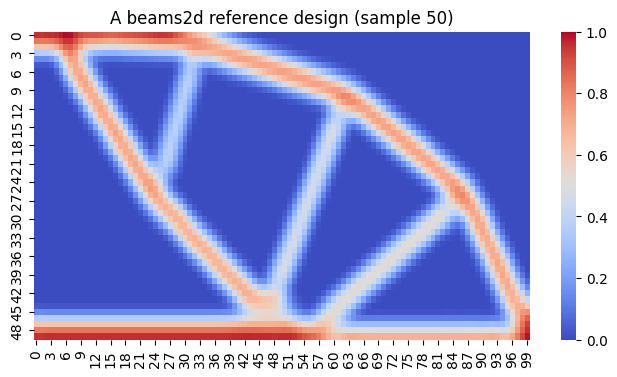

In [10]:
fig = problem.render(design)
plt.title(f"A beams2d reference design (sample {sample_idx})")
plt.show()

That's a topology-optimised beam: dark pixels are material, light pixels are void. If you stared at enough of these you'd start recognising the truss-like patterns that classical solvers produce.

---
## 7 — *When is a candidate design actually invalid?*

Here's a failure mode that catches ML researchers by surprise: your model can have low training loss *and still emit garbage*. Pixel-MSE doesn't know about physics. The network will happily output a "design" with negative material density or zero material where the solver needs at least a little.

A benchmark therefore needs an **independent validity test** — a separate function that says yes-or-no *"this candidate obeys the rules"* regardless of how it was produced.

EngiBench calls these **constraints**, and tags each one by *why* it exists:

| Category | Meaning |
|---|---|
| `THEORY` | Comes from **physics**. Values outside this are unphysical (e.g. negative volume fraction). |
| `IMPL`   | Comes from the **solver implementation**. Violating it crashes or destabilises the numerical method. |

Let's first confirm our dataset design is valid under its own scenario (it should be — it came from the solver).

In [11]:
violations = problem.check_constraints(design=design, config=config)
print(f"Checked {violations.n_constraints} constraints — {len(violations)} violated.")

Checked 16 constraints — 0 violated.


Now let's feel the other side of it. We'll lie about the volume budget by setting it to something extreme, and ask the benchmark whether the same design still qualifies under that lie.


In [12]:
bad_config = dict(config)
bad_config["volfrac"] = 0.01  # claim we only have 1% material budget

bad_violations = problem.check_constraints(design=design, config=bad_config)
print(f"Under the bad config: {len(bad_violations)} violation(s).\n")
if bad_violations:
    print(bad_violations)

Under the bad config: 2 violation(s).

check: Config.volfrac: 0.01 ∉ [0.1, 0.9]
volume_fraction_bound: Volume fraction of the design 0.1875 does not match target 0.0100 specified in the conditions. While the optimizer might fix it, this is likely to affect objective values as the initial design is not feasible given the constraints.


**What just happened.** The design itself didn't change — only the scenario we claimed it was solving. The benchmark caught the mismatch. That's the point: a benchmark's validity test is what keeps a paper honest when a flashy model happens to produce outputs that look good but break the physics.

---
## 8 — *How well does this design actually perform?*

Passing the validity test is necessary but not sufficient. The next question is: **what's the objective value?** For that we need a **simulator** — a function that takes `(design, condition)` and returns the physics score.

This is the function your method is ultimately being judged by. Not training loss. Not reconstruction error. *This*.


In [13]:
problem.reset(seed=SEED)  # clear cached FEM state from any earlier simulate call
obj_values = problem.simulate(design, config=config)
print(f"Objective(s): {problem.objectives}")
print(f"Values for this design: {obj_values}")

Objective(s): (('c', <ObjectiveDirection.MINIMIZE: 1>),)
Values for this design: [464.75580476]


That's a compliance value — you'd want a method to produce designs whose simulated compliance is **low** and **feasible**. Anything else is noise.

---
## 9 — *What's the strongest non-ML baseline?*

Before you celebrate a new method, you need to know what it has to beat. For most engineering problems there is already **a classical optimiser** that has been the workhorse for decades. A benchmark should give you direct access to it, so the comparison isn't to some watered-down version.

Running the classical optimiser from a trivial starting point yields a *reference* design and a *trajectory* showing how quickly the solver converges. Your ML method has to be compared against both — not just final quality, but how fast the baseline got there.

> **Heads-up:** this cell runs a real FEM optimiser and can take ~30s depending on hardware.

In [ ]:
problem.reset(seed=SEED)  # clear cached FEM state so optimize starts fresh

# A "trivial" starting point depends on the problem. If there is a material-budget
# condition we can fill the field at that level; otherwise fall back to the midpoint
# of the design space (e.g. photonics2d, which has no volume fraction).
if "volfrac" in problem.conditions_keys:
    fill = float(config["volfrac"])
elif "volume" in problem.conditions_keys:
    fill = float(config["volume"])
else:
    low, high = float(problem.design_space.low.min()), float(problem.design_space.high.max())
    fill = 0.5 * (low + high)

starting_point = np.full(problem.design_space.shape, fill)
optimised_design, history = problem.optimize(starting_point, config)

print(f"Optimiser ran for {len(history)} steps")
print(f"Final objective: {history[-1].obj_values}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(design, cmap="gray_r", vmin=0, vmax=1)
axes[0].set_title(f"Dataset design (obj={obj_values[0]:.3f})")
axes[0].axis("off")
axes[1].imshow(optimised_design, cmap="gray_r", vmin=0, vmax=1)
axes[1].set_title(f"Freshly optimised (obj={history[-1].obj_values[0]:.3f})")
axes[1].axis("off")
plt.tight_layout(); plt.show()

Notice the two designs look similar but not identical — classical topology optimisers are non-convex and depend on starting point. That tells you something important: **the "right answer" isn't unique**. Your benchmark has to handle that with diversity-aware metrics, which is exactly what Notebook 02 will do.

---
## Putting it together

Look back at the engineer's checklist at the top of this notebook. Here's the mapping we just built up:

| Researcher's question | What we need | Where it lives on `problem` |
|---|---|---|
| What problem am I on? | A reproducible identity | `BUILTIN_PROBLEMS["beams2d"]` |
| What am I designing? | A design space | `problem.design_space` |
| Under what scenarios? | Operating conditions | `problem.conditions_keys` |
| What does better mean? | An objective | `problem.objectives` |
| Is there prior work to learn from? | A dataset | `problem.dataset` |
| Can I see a design? | A renderer | `problem.render(design)` |
| When is a design invalid? | A validity check | `problem.check_constraints(design, config)` |
| How does this design score? | A simulator | `problem.simulate(design, config)` |
| What do I have to beat? | A classical baseline | `problem.optimize(start, config)` |

**None of those rows are API features we're selling you.** They are answers to questions you'd have to pin down yourself before running a serious experiment. The benchmark's job is to pin them down *once* so every paper can point to the same pin.

That's what "benchmarking engineering design" means in one picture.

---
## Reflect before moving on

1. Pick one row in the table above and ask: *what would go wrong in published results if this row were left implicit?*
2. Look at the `volfrac` constraint we violated. If you were reviewing a paper, how would you check the authors didn't quietly skip this test?
3. Simulation is expensive; training loss is cheap. When in a research workflow would you use each?

## Next

In **Notebook 01** we take the same eight answers and drive a simple generative model against them. In **Notebook 02** we turn the simulator and baseline into a metrics harness. The pieces you just met are the same pieces we'll keep using — you never have to re-learn them.